<a href="https://colab.research.google.com/github/WeedSmoothie/cognitive-aging-analysis/blob/main/GLM%EC%9D%84_%ED%99%9C%EC%9A%A9%ED%95%9C_fMRI_%EC%B2%AD%EA%B0%81_%EC%9E%90%EA%B7%B9_%EB%B0%98%EC%9D%91_%EB%B6%84%EC%84%9D_(SPM_Auditory_Dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# fMRI 공개 데이터 탐색 - SPM Auditory Dataset (Step 1)

**데이터셋**: SPM Auditory (Friston et al., 1995)
**출처**: nilearn 내장 fetcher → SPM 공식 서버에서 자동 다운로드 (~35MB)
**과제**: 청각 자극(spoken words) vs 휴식(rest) 블록 설계

## 왜 이 데이터인가?
- 뇌영상 분석의 표준 벤치마크 데이터로 전 세계 연구자들이 사용
- task-based fMRI의 기본 구조(블록 설계, events 파일)를 모두 갖춤
- 크기가 작아서(~35MB) 빠르게 받을 수 있음
- Step 2(전처리), Step 3(GLM 분석)으로 자연스럽게 연결 가능

## 실험 설계
- 조건 1 (rest): 아무 자극 없이 가만히 있음
- 조건 2 (active): spoken words를 듣는 청각 자극
- 블록마다 42초씩 교대 → 총 7분 스캔

**Nilearn(나이런)?**

신경영상(Neuroimaging) 데이터의 통계적 학습을 위한 파이썬(Python) 라이브러리

1. 데이터셋 불러오기
2. NIfTI fMRI 데이터 구조 이해
3. 이벤트 파일(events.tsv) 이해
4. 4D fMRI 시계열 만들기
5. 복셀 하나의 BOLD 시계열 시각화
6. 왜 복셀 하나만 보면 해석이 어려운지 이해
7. GLM으로 자극-뇌반응 관계 모델링
8. mask의 의미와 필요성 이해
9. activation map 해석
10. MNI 좌표와 뇌 영역 해석


In [4]:
!pip install nilearn nibabel matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 65.0 MB/s eta 0:00:00


In [10]:
from nilearn import datasets, plotting, image

In [18]:
from nilearn import datasets

print("SPM Auditory 데이터 다운로드 중... (~35MB, 1~2분 소요)")
data = datasets.fetch_spm_auditory()
print("\n✅ 다운로드 완료!")

print("\n반환된 데이터 키:")
for key in data.keys():
    val = data[key]
    if isinstance(val, list):
        print(f"  {key}: list ({len(val)}개)")
        if len(val) > 0:
            print(f"    첫 번째 항목 예시: {val[0]}")
    else:
        print(f"  {key}: {val}")

SPM Auditory 데이터 다운로드 중... (~35MB, 1~2분 소요)


[fetch_spm_auditory] Dataset created in /root/nilearn_data/spm_auditory

[fetch_spm_auditory] Data absent, downloading...

[fetch_spm_auditory] Downloading data from 
https://www.fil.ion.ucl.ac.uk/spm/download/data/MoAEpilot/MoAEpilot.bids.zip ...

[fetch_spm_auditory] Downloaded 3579904 of 30176409 bytes (11.9%%,    7.8s remaining)

...

[fetch_spm_auditory] Downloaded 29884416 of 30176409 bytes (99.0%%,    0.1s remaining)

[fetch_spm_auditory]  ...done. (8 seconds, 0 min)

[fetch_spm_auditory] Extracting data from /root/nilearn_data/spm_auditory/MoAEpilot.bids.zip...

[fetch_spm_auditory] .. done.


✅ 다운로드 완료!

반환된 데이터 키:
  anat: /root/nilearn_data/spm_auditory/MoAEpilot/sub-01/anat/sub-01_T1w.nii
  func: list (1개)
    첫 번째 항목 예시: /root/nilearn_data/spm_auditory/MoAEpilot/sub-01/func/sub-01_task-auditory_bold.nii
  events: /root/nilearn_data/spm_auditory/MoAEpilot/sub-01/func/sub-01_task-auditory_events.tsv
  description: .. _spm_auditory_dataset:

SPM auditory dataset

Access
------
See :func:`nilearn.datasets.fetch_spm_auditory`.

Notes
-----
These whole brain BOLD/EPI images were acquired on a modified 2T Siemens MAGNETOM Vision system.
Each acquisition consisted of 64 contiguous slices (64x64x64 3mm x 3mm x 3mm voxels).
Acquisition took 6.05 seconds, with the scan to scan repeat time (RT) set arbitrarily to 7 seconds.

96 acquisitions were made (RT= 7 seconds), in blocks of 6, giving 16 blocks of 42 seconds.
The condition for successive blocks alternated between rest and auditory stimulation,
starting with rest.

Auditory stimulation was bi-syllabic words presented binaurally

In [20]:
import nibabel as nib
import numpy as np

fmri_files = data.func  # list of 3D NIfTI files
print(f"fMRI 파일 수 (= time points 수): {len(fmri_files)}")
print(f"첫 번째 파일: {fmri_files[0]}")

first_img = nib.load(fmri_files[0])

print("\n=== fMRI 데이터 정보 ===")
print(f"  단일 볼륨 Shape (x, y, z): {first_img.shape}")
print(f"  총 time points: {len(fmri_files)}")
print(f"  Data type: {first_img.get_data_dtype()}")

print(f"\n  Affine matrix (복셀 좌표 → mm):")
print(first_img.affine)

voxel_sizes = nib.affines.voxel_sizes(first_img.affine)
print(f"\n  복셀 크기: {voxel_sizes[0]:.2f} x {voxel_sizes[1]:.2f} x {voxel_sizes[2]:.2f} mm")

header = first_img.header
tr = float(header.get_zooms()[3]) if len(header.get_zooms()) > 3 else 7.0
print(f"  TR: {tr:.1f} 초  ← 이 데이터는 TR=7초 (느린 편)")
print(f"  총 스캔 시간: {tr * len(fmri_files):.0f} 초 ({tr * len(fmri_files) / 60:.1f} 분)")



fMRI 파일 수 (= time points 수): 1
첫 번째 파일: /root/nilearn_data/spm_auditory/MoAEpilot/sub-01/func/sub-01_task-auditory_bold.nii

=== fMRI 데이터 정보 ===
  단일 볼륨 Shape (x, y, z): (64, 64, 64, 84)
  총 time points: 1
  Data type: int16

  Affine matrix (복셀 좌표 → mm):
[[ -3.   0.   0.  93.]
 [  0.   3.   0. -93.]
 [  0.   0.   3. -66.]
 [  0.   0.   0.   1.]]

  복셀 크기: 3.00 x 3.00 x 3.00 mm
  TR: 7.0 초  ← 이 데이터는 TR=7초 (느린 편)
  총 스캔 시간: 7 초 (0.1 분)


In [21]:
import pandas as pd

events = pd.read_csv(data.events, sep='\t')

print("=== 실험 이벤트 파일 ===")
print(f"총 블록 수: {len(events)}")
print(f"열(column): {list(events.columns)}")
print()
print(events.to_string(index=False))

print("\n=== 조건별 요약 ===")
summary = events.groupby('trial_type').agg(
    블록수=('onset', 'count'),
    평균_지속시간=('duration', 'mean'),
    총_지속시간=('duration', 'sum')
)
print(summary)

=== 실험 이벤트 파일 ===
총 블록 수: 7
열(column): ['onset', 'duration', 'trial_type']

 onset  duration trial_type
    42        42  listening
   126        42  listening
   210        42  listening
   294        42  listening
   378        42  listening
   462        42  listening
   546        42  listening

=== 조건별 요약 ===
            블록수  평균_지속시간  총_지속시간
trial_type                      
listening     7     42.0     294


In [28]:
print("=== trial_type 확인 ===")
print(events['trial_type'].unique())
print(events['trial_type'].value_counts())

print("\n=== 원본 onset/duration 범위 ===")
print(events[['onset', 'duration']].head(10))
print("max onset:", events['onset'].max())
print("n_scans:", n_scans)
print("times max:", times.max())

print("\n=== 변환 후 onset/duration 범위 ===")
print(events_sec[['onset', 'duration', 'trial_type']].head(10))
print("max event end:", (events_sec['onset'] + events_sec['duration']).max())

active_blocks = events_sec[events_sec['trial_type'] == 'active']
print("\nactive block 개수:", len(active_blocks))
print(active_blocks.head())

=== trial_type 확인 ===
['listening']
trial_type
listening    7
Name: count, dtype: int64

=== 원본 onset/duration 범위 ===
   onset  duration
0     42        42
1    126        42
2    210        42
3    294        42
4    378        42
5    462        42
6    546        42
max onset: 546
n_scans: 84
times max: 581.0

=== 변환 후 onset/duration 범위 ===
   onset  duration trial_type
0     42        42  listening
1    126        42  listening
2    210        42  listening
3    294        42  listening
4    378        42  listening
5    462        42  listening
6    546        42  listening
max event end: 588

active block 개수: 0
Empty DataFrame
Columns: [onset, duration, trial_type]
Index: []


/tmp/ipykernel_1654/732690696.py:25: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1654/732690696.py:25: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1654/732690696.py:25: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1654/732690696.py:25: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1654/732690696.py:25: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1654/732690696.py:25: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1654/732690696.py:25: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

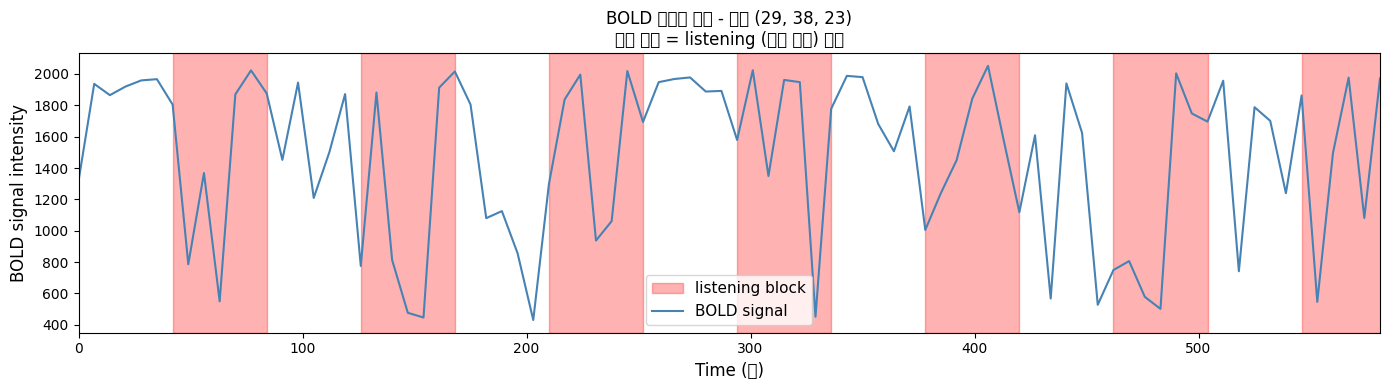

In [29]:
fig, ax = plt.subplots(figsize=(14, 4))

listening_blocks = events_sec[events_sec['trial_type'] == 'listening']

for i, (_, row) in enumerate(listening_blocks.iterrows()):
    ax.axvspan(
        row['onset'],
        row['onset'] + row['duration'],
        alpha=0.3,
        color='red',
        label='listening block' if i == 0 else ''
    )

ax.plot(times, bold_signal, color='steelblue', linewidth=1.5, label='BOLD signal')

ax.set_xlim(times.min(), times.max())
ax.set_xlabel('Time (초)', fontsize=12)
ax.set_ylabel('BOLD signal intensity', fontsize=12)
ax.set_title(
    f'BOLD 시계열 신호 - 복셀 ({bx}, {by}, {bz})\n'
    f'빨간 배경 = listening (청각 자극) 블록',
    fontsize=12
)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

4D fMRI shape: (64, 64, 64, 84)
4D header zooms: (np.float32(3.0), np.float32(3.0), np.float32(3.0), np.float32(7.0))

=== events 확인 ===
   onset  duration trial_type
0     42        42  listening
1    126        42  listening
2    210        42  listening
3    294        42  listening
4    378        42  listening
5    462        42  listening
6    546        42  listening

trial_type unique: ['listening']

=== GLM에 들어갈 events ===
   onset  duration trial_type
0   42.0      42.0  listening
1  126.0      42.0  listening
2  210.0      42.0  listening
3  294.0      42.0  listening
4  378.0      42.0  listening
5  462.0      42.0  listening
6  546.0      42.0  listening


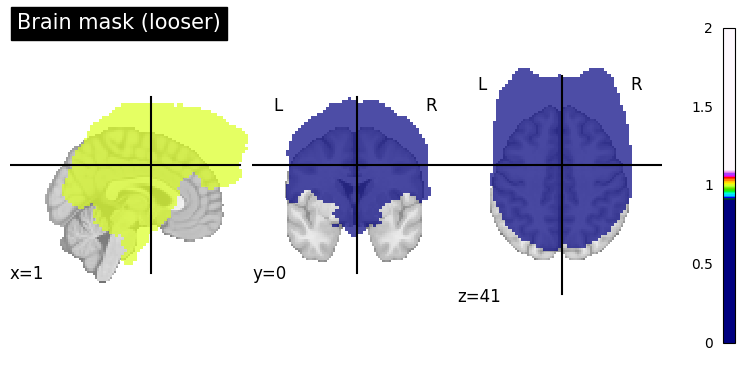


✅ GLM fit 완료

=== design matrix columns ===
['listening', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'drift_6', 'drift_7', 'drift_8', 'drift_9', 'drift_10', 'drift_11', 'constant']


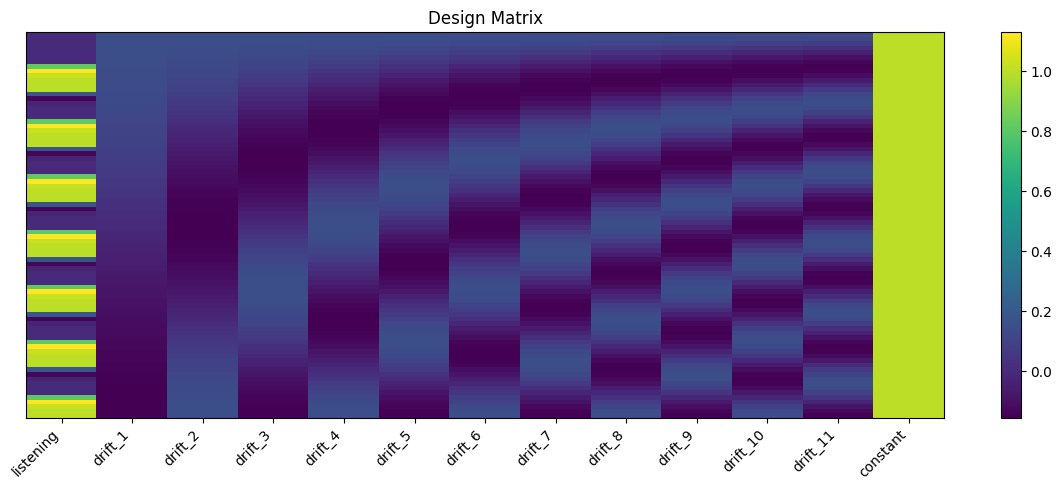


✅ contrast 계산 완료


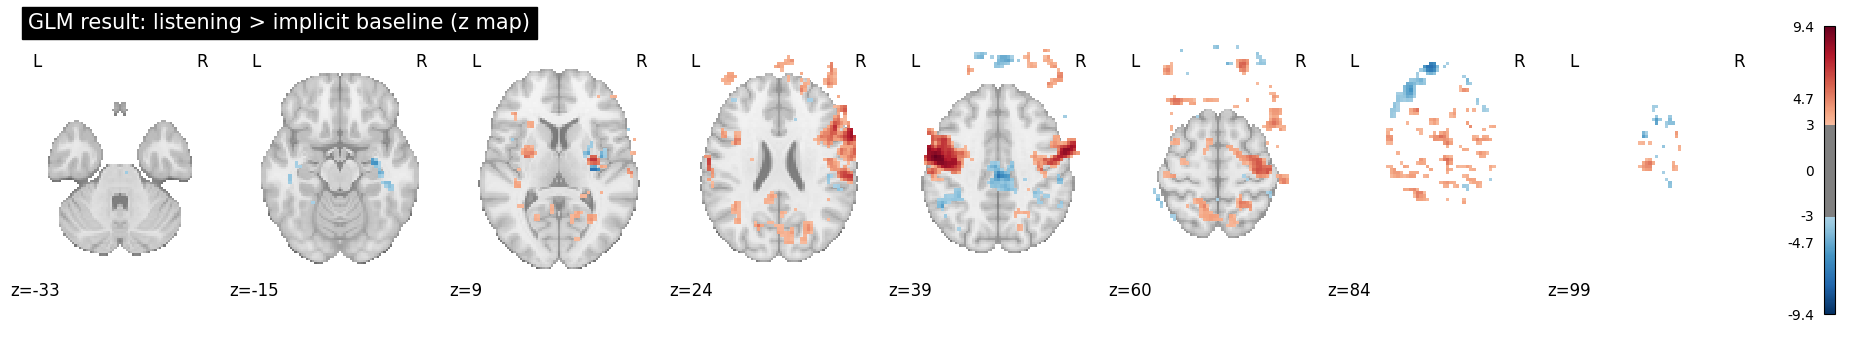

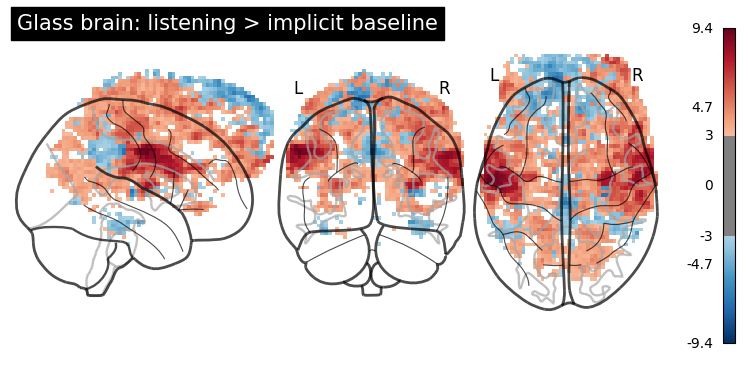


가장 강한 activation 중심 좌표 (대략, MNI mm): [-51.58411149592527, -3.8274537284149517, 37.99686502315767]


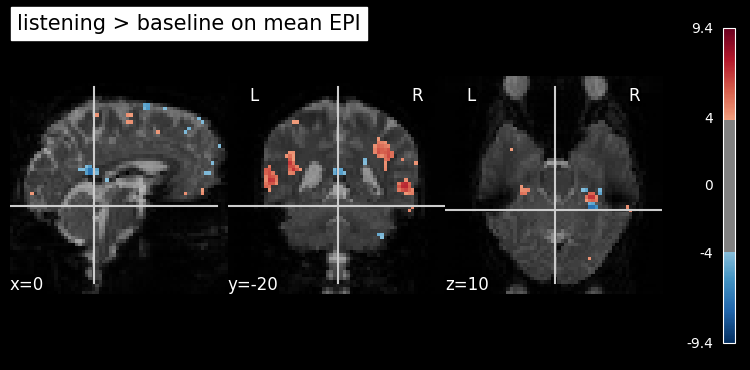

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import image, plotting
from nilearn.glm.first_level import FirstLevelModel

# --------------------------------------------------
# 1) fMRI 4D 이미지 만들기
# --------------------------------------------------
fmri_4d = image.concat_imgs(fmri_files)

print("4D fMRI shape:", fmri_4d.shape)
print("4D header zooms:", fmri_4d.header.get_zooms())

# --------------------------------------------------
# 2) events 읽기
# --------------------------------------------------
events = pd.read_csv(data.events, sep="\t")

print("\n=== events 확인 ===")
print(events)
print("\ntrial_type unique:", events["trial_type"].unique())

# SPM auditory는 onset/duration이 이미 초 단위
events_glm = events.copy()

# 혹시 필요하면 문자열/형 변환 안전하게
events_glm["onset"] = events_glm["onset"].astype(float)
events_glm["duration"] = events_glm["duration"].astype(float)
events_glm["trial_type"] = events_glm["trial_type"].astype(str)

print("\n=== GLM에 들어갈 events ===")
print(events_glm)

# --------------------------------------------------
# 3) GLM 적합
# --------------------------------------------------
# TR = 7.0초
# smoothing_fwhm은 약간 부드럽게 해서 신호 보기 좋게 만듦
# mask_img=None이면 nilearn이 자동으로 마스크 생성

from nilearn.masking import compute_epi_mask

fmri_4d = image.concat_imgs(fmri_files)
mask = compute_epi_mask(
    fmri_4d,
    lower_cutoff=0.2,
    upper_cutoff=0.85,
    connected=True,
    opening=1
)

plotting.plot_roi(mask, title="Brain mask (looser)")
plotting.show()
glm = FirstLevelModel(
    t_r=7.0,
    hrf_model="spm",
    drift_model="cosine",
    high_pass=0.01,
    slice_time_ref=0.0,
    smoothing_fwhm=6.0,
    mask_img=mask,
    minimize_memory=False
)
glm = glm.fit(fmri_4d, events=events_glm)

print("\n✅ GLM fit 완료")

# --------------------------------------------------
# 4) 디자인 매트릭스 확인
# --------------------------------------------------
design_matrix = glm.design_matrices_[0]

print("\n=== design matrix columns ===")
print(design_matrix.columns.tolist())

plt.figure(figsize=(12, 5))
plt.imshow(design_matrix, aspect="auto", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(design_matrix.columns)), design_matrix.columns, rotation=45, ha="right")
plt.yticks([])
plt.title("Design Matrix")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 5) contrast 계산
# --------------------------------------------------
# listening 컬럼이 있는지 확인
if "listening" not in design_matrix.columns:
    raise ValueError(f"'listening' column not found. columns = {design_matrix.columns.tolist()}")

z_map = glm.compute_contrast("listening", output_type="z_score")
beta_map = glm.compute_contrast("listening", output_type="effect_size")

print("\n✅ contrast 계산 완료")

# --------------------------------------------------
# 6) 결과 시각화
# --------------------------------------------------
# z-score threshold는 일단 3.0 정도로 시작
plotting.plot_stat_map(
    z_map,
    threshold=3.0,
    display_mode="z",
    cut_coords=8,
    black_bg=False,
    title="GLM result: listening > implicit baseline (z map)"
)
plotting.show()

# --------------------------------------------------
# 7) glass brain 보기
# --------------------------------------------------
plotting.plot_glass_brain(
    z_map,
    threshold=3.0,
    colorbar=True,
    plot_abs=False,
    title="Glass brain: listening > implicit baseline"
)
plotting.show()

# --------------------------------------------------
# 8) 가장 강한 activation 좌표 확인
# --------------------------------------------------
from nilearn.plotting import find_xyz_cut_coords

peak_coord = find_xyz_cut_coords(z_map)
print("\n가장 강한 activation 중심 좌표 (대략, MNI mm):", peak_coord)

# --------------------------------------------------
# 9) peak 위치를 crosshair로 다시 보기
# --------------------------------------------------
plotting.plot_stat_map(
    z_map,
    bg_img=image.mean_img(fmri_4d),
    threshold=4.0,
    display_mode="ortho",
    cut_coords=(0, -20, 10),
    title="listening > baseline on mean EPI"
)
plotting.show()